In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\CV\fntest\features04_grade.csv")
plant = df['number'] 
df = df.drop(['filename', 'number', 'day'], axis=1)   # filename/day ไม่ใช่ feature
df

,height_px,length_px,area_px,green_area_px,black_area_px,white_area_px,brown_area_px,green_intensity,grade
0,532,762,297412,221512,36150,39438,312,45.47,B
1,624,726,313801,245545,55599,12017,640,47.28,A
2,582,678,265205,210441,30181,24583,0,49.64,C
3,621,716,283742,210339,46892,26376,135,46.58,B
4,781,751,287483,225725,33414,27933,411,46.06,A
...,...,...,...,...,...,...,...,...,...
715,515,732,254872,206903,31138,16658,173,45.22,C
716,590,806,302431,233115,27273,41434,609,44.81,A
717,487,751,277281,210051,45452,21555,223,43.33,B
718,566,769,304482,225683,34905,43730,164,42.68,B


In [3]:
display(df.dtypes)
display(df.shape)
display(df.columns)

height_px            int64
length_px            int64
area_px              int64
green_area_px        int64
black_area_px        int64
white_area_px        int64
brown_area_px        int64
green_intensity    float64
grade               object
dtype: object

(720, 9)

Index(['height_px', 'length_px', 'area_px', 'green_area_px', 'black_area_px',
       'white_area_px', 'brown_area_px', 'green_intensity', 'grade'],
      dtype='object')

<Axes: xlabel='area_px', ylabel='brown_area_px'>

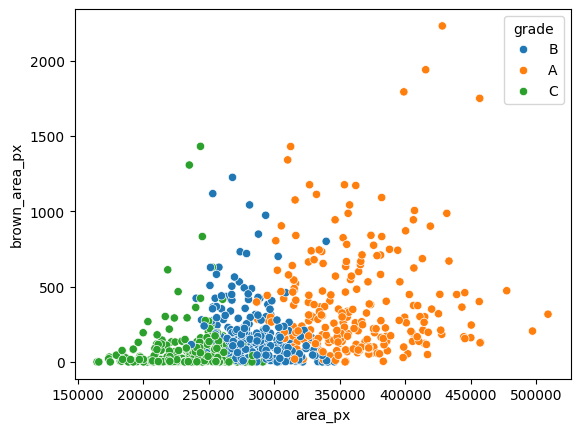

In [4]:
sns.scatterplot(x='area_px', y='brown_area_px', data=df, hue='grade')

<Axes: xlabel='area_px', ylabel='black_area_px'>

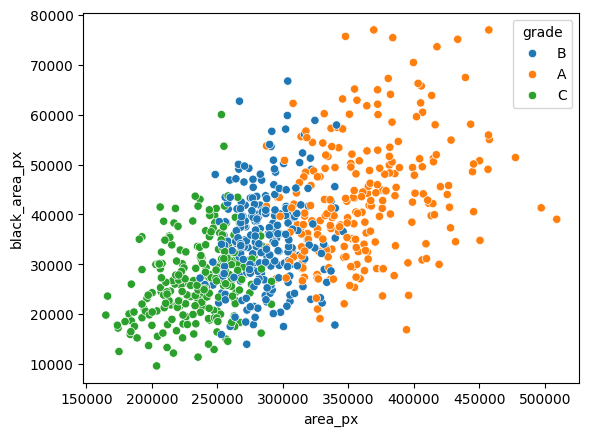

In [5]:
sns.scatterplot(x='area_px', y='black_area_px', data=df, hue='grade')

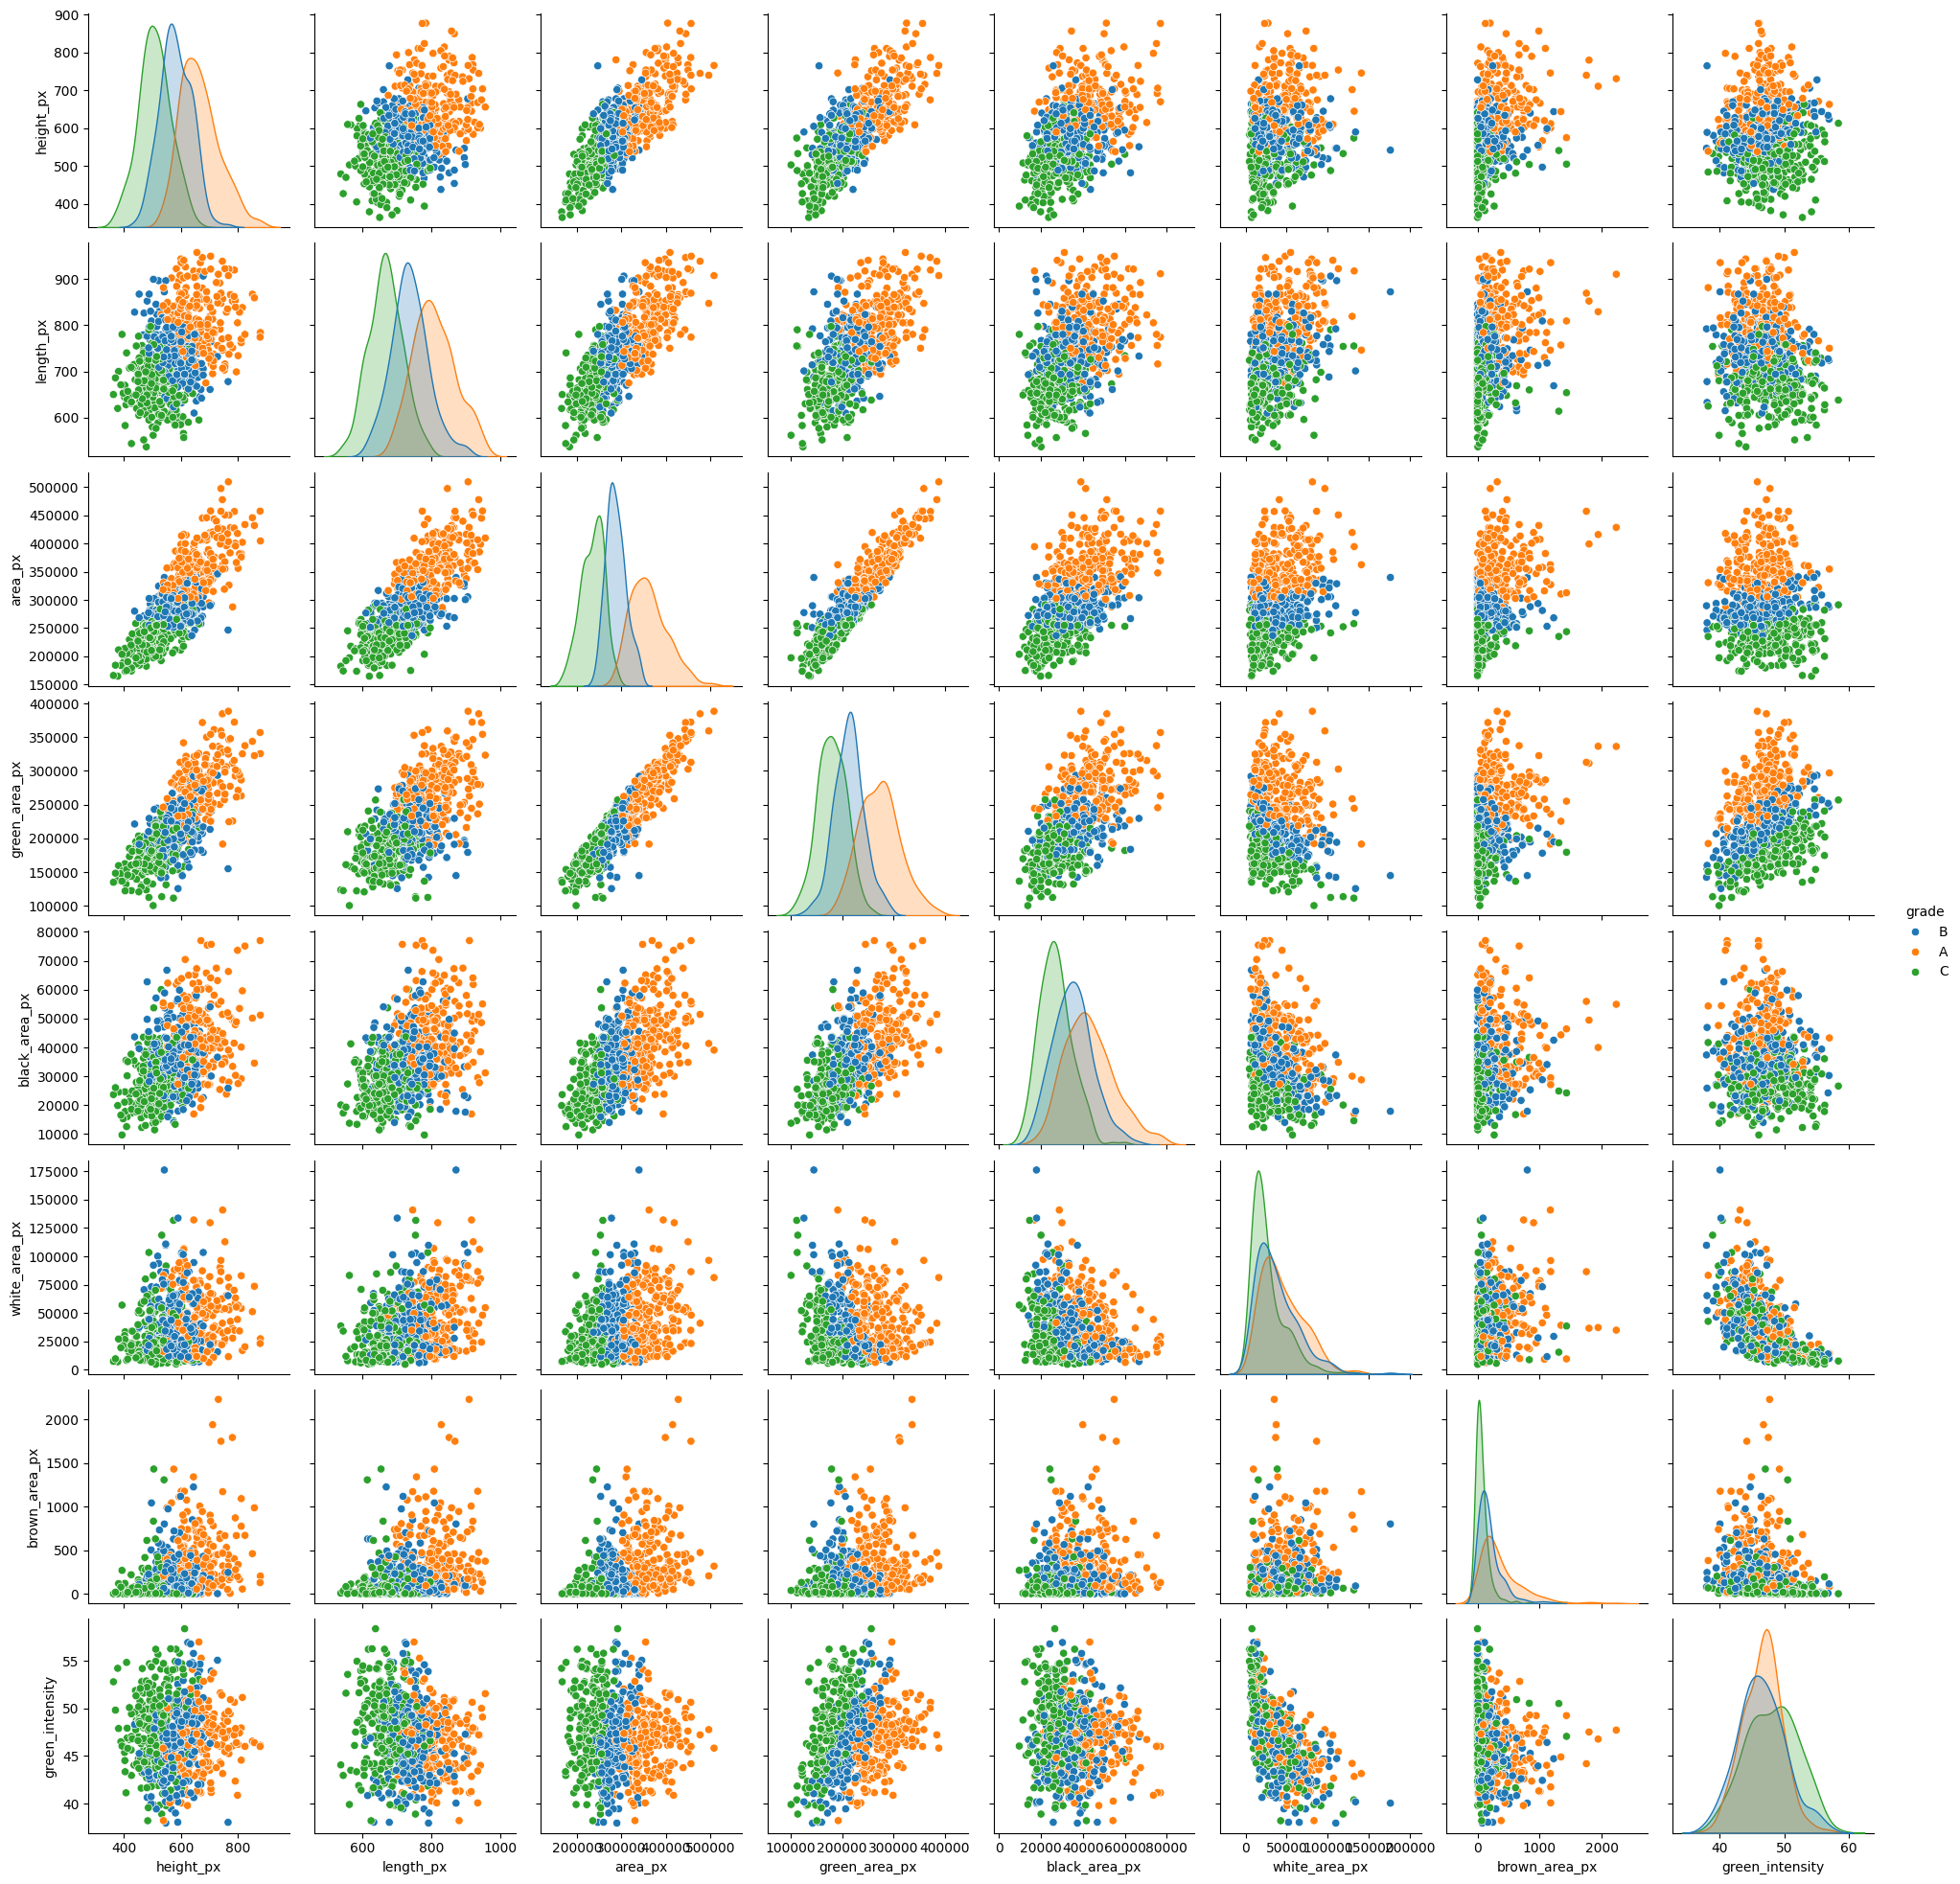

In [6]:
sns.pairplot(df, hue='grade')

In [7]:
from sklearn.preprocessing import LabelEncoder
lb_make = LabelEncoder()
df['grade'] = lb_make.fit_transform(df['grade'])
df

,height_px,length_px,area_px,green_area_px,black_area_px,white_area_px,brown_area_px,green_intensity,grade
0,532,762,297412,221512,36150,39438,312,45.47,1
1,624,726,313801,245545,55599,12017,640,47.28,0
2,582,678,265205,210441,30181,24583,0,49.64,2
3,621,716,283742,210339,46892,26376,135,46.58,1
4,781,751,287483,225725,33414,27933,411,46.06,0
...,...,...,...,...,...,...,...,...,...
715,515,732,254872,206903,31138,16658,173,45.22,2
716,590,806,302431,233115,27273,41434,609,44.81,0
717,487,751,277281,210051,45452,21555,223,43.33,1
718,566,769,304482,225683,34905,43730,164,42.68,1


In [8]:
y = df[['grade']]
y

,grade
0,1
1,0
2,2
3,1
4,0
...,...
715,2
716,0
717,1
718,1


In [9]:
X = df.drop('grade', axis=1)
X

,height_px,length_px,area_px,green_area_px,black_area_px,white_area_px,brown_area_px,green_intensity
0,532,762,297412,221512,36150,39438,312,45.47
1,624,726,313801,245545,55599,12017,640,47.28
2,582,678,265205,210441,30181,24583,0,49.64
3,621,716,283742,210339,46892,26376,135,46.58
4,781,751,287483,225725,33414,27933,411,46.06
...,...,...,...,...,...,...,...,...
715,515,732,254872,206903,31138,16658,173,45.22
716,590,806,302431,233115,27273,41434,609,44.81
717,487,751,277281,210051,45452,21555,223,43.33
718,566,769,304482,225683,34905,43730,164,42.68


In [10]:
# แบ่ง train/test รายต้น ตามช่วงเลขต้น (1-10, 11-20, 21-30) สุ่มกลุ่มละ 3 ต้นเป็น test
# seed = 1 (np.random.RandomState(1)) ตรึงไว้ตรงนี้ รันรอบต่อไปจะได้ชุด test ต้นเดิมทุกครั้ง
group = (plant - 1) // 10                    # 1-10->0, 11-20->1, 21-30->2

rng = np.random.RandomState(1)
test_plants = []
for g in [0, 1, 2]:
    test_plants += list(rng.choice(plant[group == g].unique(), size=3, replace=False))

is_test = plant.isin(test_plants)
X_train, X_test = X[~is_test.values], X[is_test.values]
y_train, y_test = y[~is_test.values], y[is_test.values]

print('train:', len(X_train), '| test:', len(X_test))
print('test:', sorted(int(p) for p in test_plants))

train: 504 | test: 216
test: [3, 7, 10, 14, 16, 20, 24, 26, 29]


In [11]:
from sklearn import tree
model = tree.DecisionTreeClassifier()
model = model.fit(X_train, y_train)

In [12]:
model.score(X_train, y_train)

1.0

In [13]:
model.score(X_test, y_test)

0.8518518518518519

In [14]:
y_prediction = model.predict([[488,748,266860,205691,38277,22887,5,46.22]])
y_prediction

C:\Users\kbbos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([2])

# ตารางผลการทดลอง (เพิ่มต่อจากของเดิม ไม่แก้ของเดิม)

In [15]:
grade_name = lb_make.inverse_transform(sorted(y['grade'].unique()))

dist_table = pd.DataFrame({
    'grade': grade_name,
    'total': y['grade'].value_counts().sort_index().values,
    'train': y_train['grade'].value_counts().sort_index().values,
    'test': y_test['grade'].value_counts().sort_index().values,
})
dist_table

,grade,total,train,test
0,A,240,164,76
1,B,240,175,65
2,C,240,165,75


## Baseline (ทายกลุ่มที่เยอะสุดเสมอ) เทียบกับ DecisionTree

In [16]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent')
baseline = baseline.fit(X_train, y_train)
baseline_test_acc = baseline.score(X_test, y_test)

print('baseline (most_frequent) test accuracy:', baseline_test_acc)
print('DecisionTree (default) test accuracy   :', model.score(X_test, y_test))

baseline (most_frequent) test accuracy: 0.30092592592592593
DecisionTree (default) test accuracy   : 0.8518518518518519


## เปรียบเทียบ max_depth / min_samples_leaf ด้วย cross-validation (แก้ปัญหา overfit)

In [17]:
from sklearn.model_selection import cross_val_score

depth_list = [2, 3, 4, 5, 6, 8, 10, None]
leaf_list = [1, 3, 5, 10]

rows = []
for max_depth in depth_list:
    for min_samples_leaf in leaf_list:
        candidate = tree.DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=1,
        )
        cv_scores = cross_val_score(candidate, X_train, y_train.values.ravel(), cv=5)
        candidate = candidate.fit(X_train, y_train)
        rows.append({
            'max_depth': max_depth,
            'min_samples_leaf': min_samples_leaf,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'train_acc': candidate.score(X_train, y_train),
            'test_acc': candidate.score(X_test, y_test),
        })

hp_table = pd.DataFrame(rows).sort_values('cv_mean', ascending=False).reset_index(drop=True)
hp_table

,max_depth,min_samples_leaf,cv_mean,cv_std,train_acc,test_acc
0,4.0,3,0.866950,0.047968,0.928571,0.833333
1,4.0,1,0.866931,0.049281,0.932540,0.833333
2,4.0,10,0.863010,0.060443,0.918651,0.856481
3,3.0,10,0.859050,0.059767,0.890873,0.819444
4,2.0,3,0.859010,0.046682,0.869048,0.842593
5,2.0,1,0.859010,0.046682,0.869048,0.842593
6,10.0,3,0.855109,0.037056,0.972222,0.851852
7,NaN,3,0.855109,0.037056,0.972222,0.851852
8,8.0,3,0.853129,0.039498,0.972222,0.851852
9,2.0,10,0.853069,0.050274,0.869048,0.842593


In [18]:
best_row = hp_table.iloc[0]
best_max_depth = None if pd.isna(best_row['max_depth']) else int(best_row['max_depth'])
best_min_samples_leaf = int(best_row['min_samples_leaf'])

best_model = tree.DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_leaf=best_min_samples_leaf,
    random_state=1,
)
best_model = best_model.fit(X_train, y_train)

print('best max_depth        :', best_max_depth)
print('best min_samples_leaf :', best_min_samples_leaf)
print('train accuracy        :', best_model.score(X_train, y_train))
print('test accuracy         :', best_model.score(X_test, y_test))

best max_depth        : 4
best min_samples_leaf : 3
train accuracy        : 0.9285714285714286
test accuracy         : 0.8333333333333334


## Confusion matrix และ classification report ของ best_model

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_test = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
cm_table = pd.DataFrame(
    cm,
    index=[f'actual_{g}' for g in grade_name],
    columns=[f'pred_{g}' for g in grade_name],
)
cm_table

,pred_A,pred_B,pred_C
actual_A,71,5,0
actual_B,10,43,12
actual_C,0,9,66


In [20]:
print(classification_report(y_test, y_pred_test, target_names=grade_name))

              precision    recall  f1-score   support

           A       0.88      0.93      0.90        76
           B       0.75      0.66      0.70        65
           C       0.85      0.88      0.86        75

    accuracy                           0.83       216
   macro avg       0.83      0.83      0.82       216
weighted avg       0.83      0.83      0.83       216



## Feature importance ของ best_model

In [21]:
importance_table = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_table

,feature,importance
0,area_px,0.788494
1,brown_area_px,0.124252
2,length_px,0.043756
3,height_px,0.026324
4,green_intensity,0.017174
5,green_area_px,0.000000
6,white_area_px,0.000000
7,black_area_px,0.000000


## วาดโครงสร้างต้นไม้ของ best_model (ดูกฎการตัดสินใจจริง)

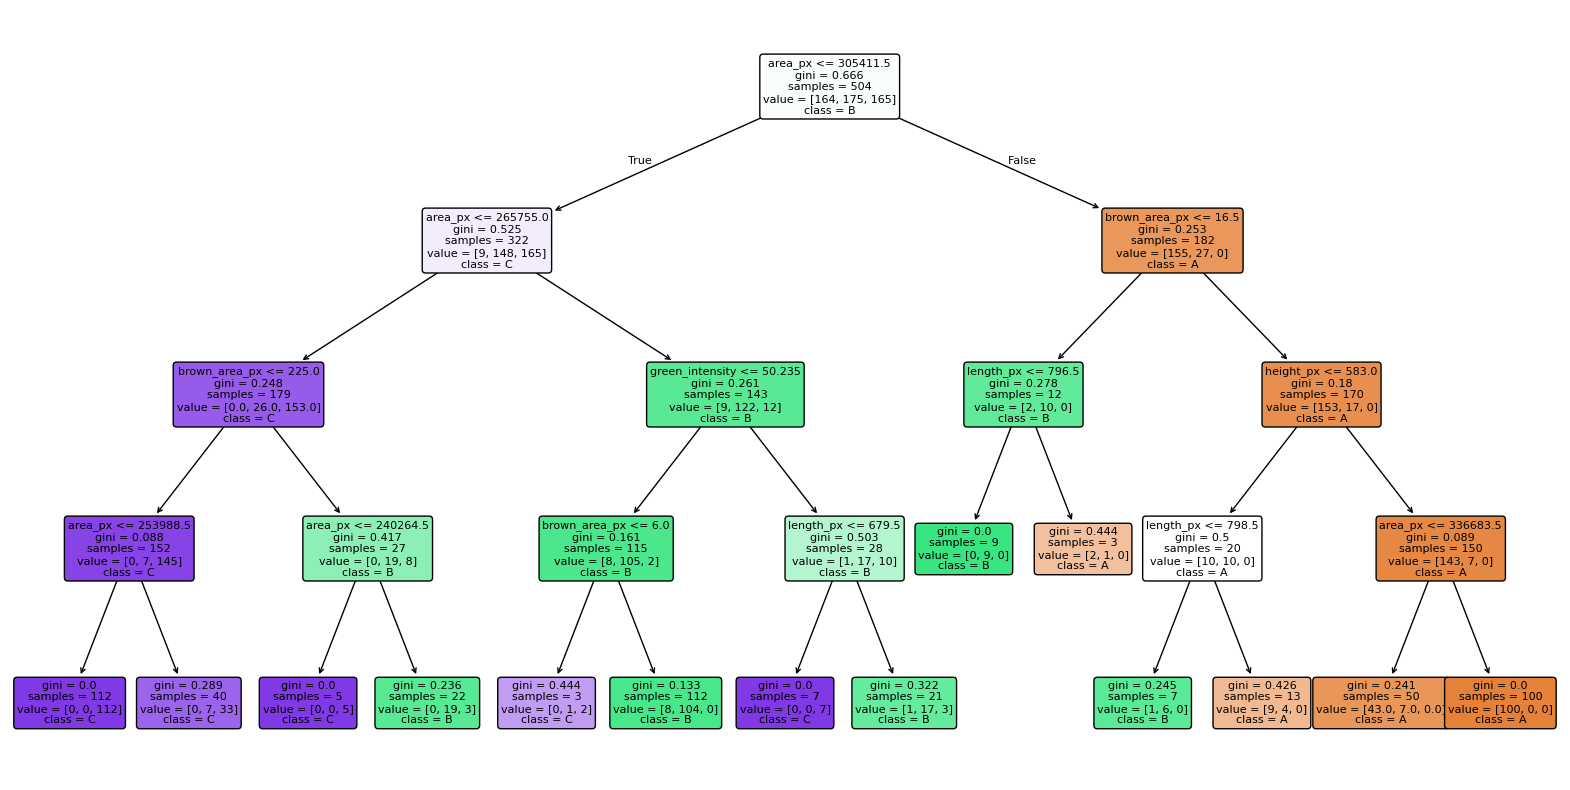

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
tree.plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=grade_name,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.show()

In [23]:
print('=== สรุปผลการทดลอง ===')
print('baseline (most_frequent) test accuracy :', baseline_test_acc)
print('DecisionTree default test accuracy     :', model.score(X_test, y_test), '(train acc =', model.score(X_train, y_train), '-> overfit)')
print('best_model test accuracy               :', best_model.score(X_test, y_test))
print('best_model params                      : max_depth =', best_max_depth, ', min_samples_leaf =', best_min_samples_leaf)
print('feature สำคัญสุด 3 อันดับแรก             :', list(importance_table['feature'][:3]))

=== สรุปผลการทดลอง ===
baseline (most_frequent) test accuracy : 0.30092592592592593
DecisionTree default test accuracy     : 0.8518518518518519 (train acc = 1.0 -> overfit)
best_model test accuracy               : 0.8333333333333334
best_model params                      : max_depth = 4 , min_samples_leaf = 3
feature สำคัญสุด 3 อันดับแรก             : ['area_px', 'brown_area_px', 'length_px']


## ทดลองตัดฟีเจอร์ที่ importance = 0 ออก (green_area_px, white_area_px, black_area_px)

In [26]:
drop_cols = importance_table.loc[importance_table['importance'] == 0, 'feature'].tolist()

X_train_reduced = X_train.drop(columns=drop_cols)
X_test_reduced = X_test.drop(columns=drop_cols)

print('ตัดออก   :', drop_cols)
print('เหลือ feature:', list(X_train_reduced.columns))

ตัดออก   : ['green_area_px', 'white_area_px', 'black_area_px']
เหลือ feature: ['height_px', 'length_px', 'area_px', 'brown_area_px', 'green_intensity']


In [27]:
rows_reduced = []
for max_depth in depth_list:
    for min_samples_leaf in leaf_list:
        candidate = tree.DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=1,
        )
        cv_scores = cross_val_score(candidate, X_train_reduced, y_train.values.ravel(), cv=5)
        candidate = candidate.fit(X_train_reduced, y_train)
        rows_reduced.append({
            'max_depth': max_depth,
            'min_samples_leaf': min_samples_leaf,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'train_acc': candidate.score(X_train_reduced, y_train),
            'test_acc': candidate.score(X_test_reduced, y_test),
        })

hp_table_reduced = pd.DataFrame(rows_reduced).sort_values('cv_mean', ascending=False).reset_index(drop=True)

best_row_reduced = hp_table_reduced.iloc[0]
best_max_depth_reduced = None if pd.isna(best_row_reduced['max_depth']) else int(best_row_reduced['max_depth'])
best_min_samples_leaf_reduced = int(best_row_reduced['min_samples_leaf'])

reduced_model = tree.DecisionTreeClassifier(
    max_depth=best_max_depth_reduced,
    min_samples_leaf=best_min_samples_leaf_reduced,
    random_state=1,
)
reduced_model = reduced_model.fit(X_train_reduced, y_train)

hp_table_reduced.head()

,max_depth,min_samples_leaf,cv_mean,cv_std,train_acc,test_acc
0,4.0,3,0.884891,0.033010,0.928571,0.833333
1,4.0,1,0.878931,0.037394,0.932540,0.837963
2,10.0,3,0.863050,0.044173,0.964286,0.851852
3,NaN,3,0.863050,0.044173,0.964286,0.851852
4,4.0,10,0.863010,0.060443,0.918651,0.856481


In [28]:
compare_table = pd.DataFrame([
    {
        'model': 'best_model (8 features)',
        'n_features': X_train.shape[1],
        'max_depth': best_max_depth,
        'min_samples_leaf': best_min_samples_leaf,
        'cv_mean': hp_table.iloc[0]['cv_mean'],
        'train_acc': best_model.score(X_train, y_train),
        'test_acc': best_model.score(X_test, y_test),
    },
    {
        'model': 'reduced_model (5 features)',
        'n_features': X_train_reduced.shape[1],
        'max_depth': best_max_depth_reduced,
        'min_samples_leaf': best_min_samples_leaf_reduced,
        'cv_mean': hp_table_reduced.iloc[0]['cv_mean'],
        'train_acc': reduced_model.score(X_train_reduced, y_train),
        'test_acc': reduced_model.score(X_test_reduced, y_test),
    },
])
compare_table

,model,n_features,max_depth,min_samples_leaf,cv_mean,train_acc,test_acc
0,best_model (8 features),8,4,3,0.866950,0.928571,0.833333
1,reduced_model (5 features),5,4,3,0.884891,0.928571,0.833333


## วาดโครงสร้างต้นไม้ของ reduced_model เทียบกับ best_model

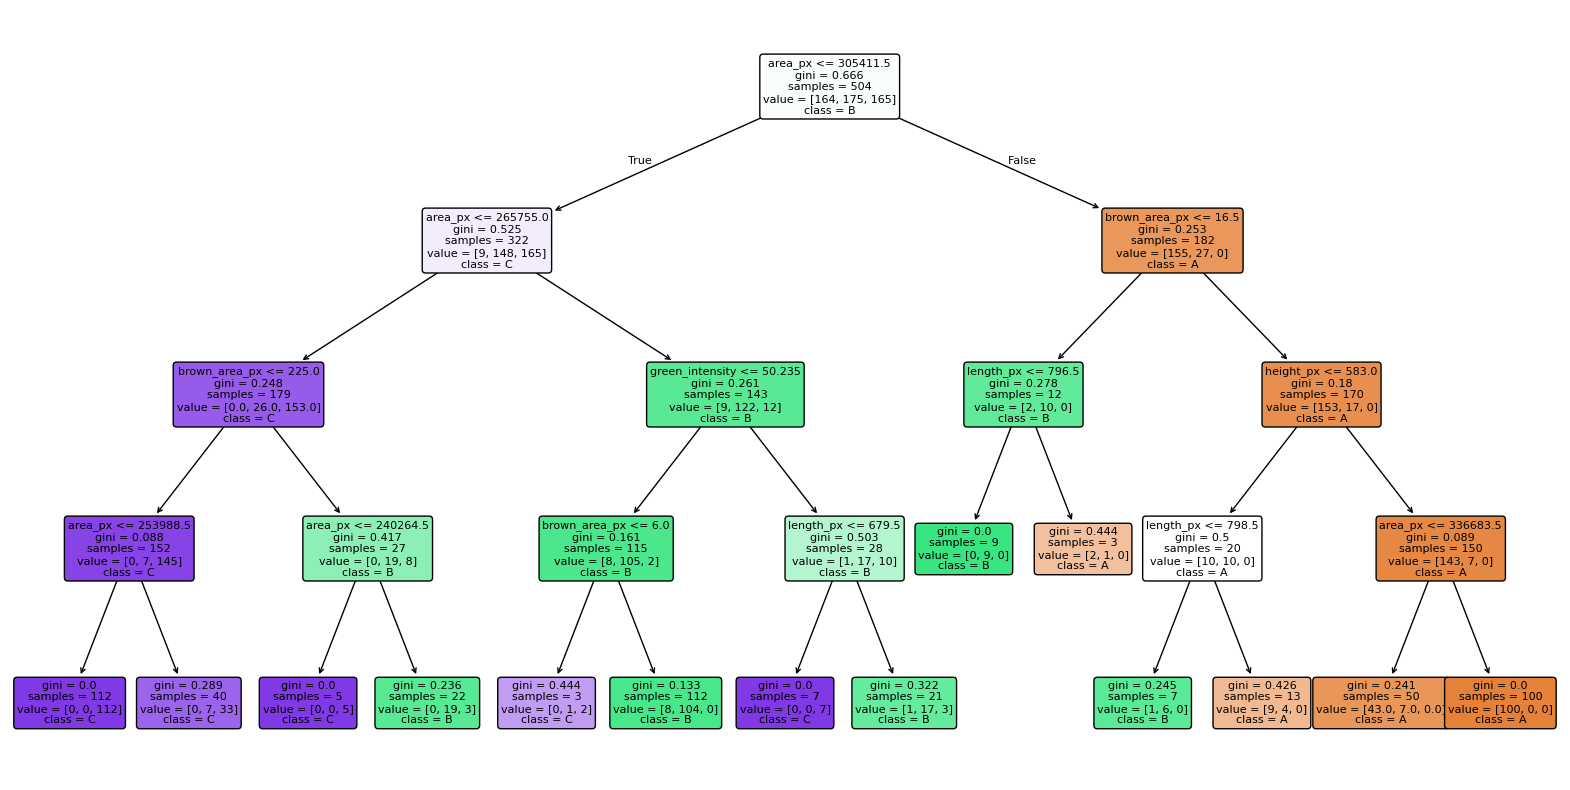

In [29]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    reduced_model,
    feature_names=X_train_reduced.columns,
    class_names=grade_name,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.show()

## แก้ปัญหา grade B สับสน — เริ่มจากดูก่อนว่าสับสนเพราะอะไร (ยังไม่รีบแก้)

In [30]:
test_result = X_test.copy()
test_result['actual'] = lb_make.inverse_transform(y_test['grade'])
test_result['predicted'] = lb_make.inverse_transform(y_pred_test)
test_result['correct'] = test_result['actual'] == test_result['predicted']

wrong_b = test_result[(test_result['actual'] == 'B') & (~test_result['correct'])]
wrong_b[['area_px', 'brown_area_px', 'length_px', 'height_px', 'green_intensity', 'actual', 'predicted']]

,area_px,brown_area_px,length_px,height_px,green_intensity,actual,predicted
50,331498,44,750,637,50.50,B,A
55,316369,5,835,586,48.16,B,A
145,320942,34,741,606,50.87,B,A
146,279697,3,763,505,48.42,B,C
149,302071,2,845,513,48.93,B,C
218,303606,0,823,516,49.24,B,C
326,248309,61,742,540,41.87,B,C
375,321265,178,743,608,43.89,B,A
376,305814,72,676,626,42.62,B,A
381,311366,263,670,595,46.54,B,A


In [31]:
df_with_letter = df.copy()
df_with_letter['grade'] = lb_make.inverse_transform(df_with_letter['grade'])

range_table = df_with_letter.groupby('grade')[['area_px', 'brown_area_px']].agg(['min', 'mean', 'max'])
range_table

area_px                        brown_area_px                  
          min           mean     max           min        mean   max
grade                                                               
A      286540  361716.475000  508964             0  375.566667  2232
B      236715  286987.962500  345895             0  192.208333  1226
C      164819  233958.854167  291254             0   77.062500  1432

C:\Users\kbbos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kbbos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kbbos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kbbos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\l

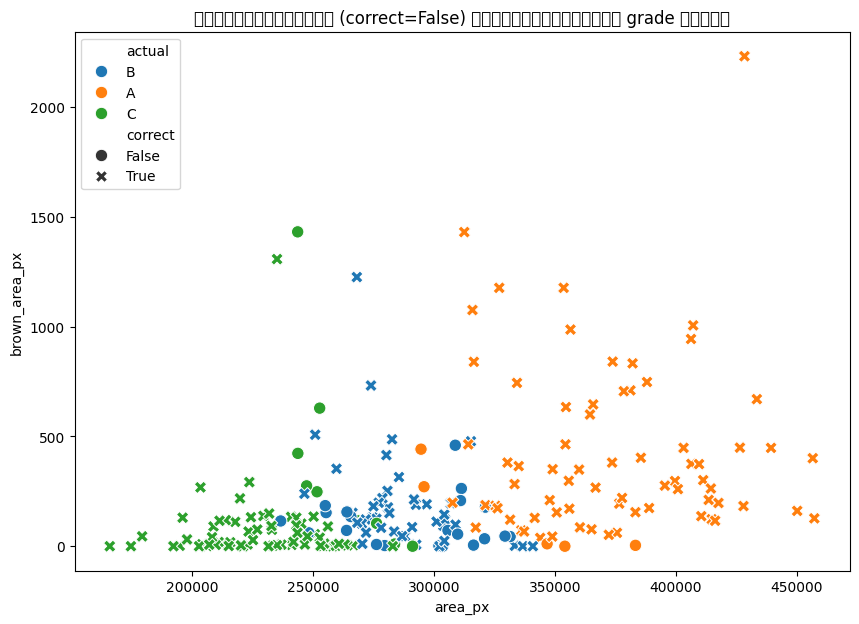

In [32]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='area_px', y='brown_area_px', data=test_result, hue='actual', style='correct', s=80)
plt.title('จุดที่ทำนายผิด (correct=False) เทียบตำแหน่งกับ grade อื่นๆ')
plt.show()